In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns


In [2]:
data = pd.read_csv('iris.csv')
data.head()

,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
print('data shape: ', data.shape)

data shape:  (150, 5)


In [5]:
data.describe()

,150,4,setosa,versicolor,virginica
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
num = data.drop(columns=['species'],errors='ignore')

In [8]:
correlation_matrix = num.corr(method='pearson')
print( 'correlation matrix: \n', correlation_matrix)

correlation matrix: 
                  150         4    setosa  versicolor  virginica
150         1.000000 -0.117570  0.871754    0.817941   0.782561
4          -0.117570  1.000000 -0.428440   -0.366126  -0.426658
setosa      0.871754 -0.428440  1.000000    0.962865   0.949035
versicolor  0.817941 -0.366126  0.962865    1.000000   0.956547
virginica   0.782561 -0.426658  0.949035    0.956547   1.000000


In [9]:
correlation_matrix.round(4)

,150,4,setosa,versicolor,virginica
150,1.0000,-0.1176,0.8718,0.8179,0.7826
4,-0.1176,1.0000,-0.4284,-0.3661,-0.4267
setosa,0.8718,-0.4284,1.0000,0.9629,0.9490
versicolor,0.8179,-0.3661,0.9629,1.0000,0.9565
virginica,0.7826,-0.4267,0.9490,0.9565,1.0000


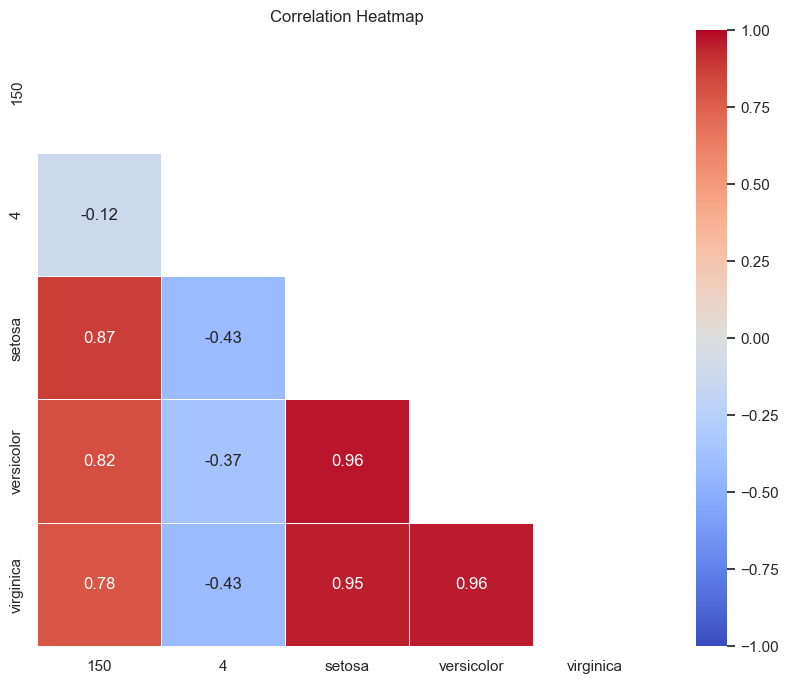

In [10]:
sns.set_theme(style='white')
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

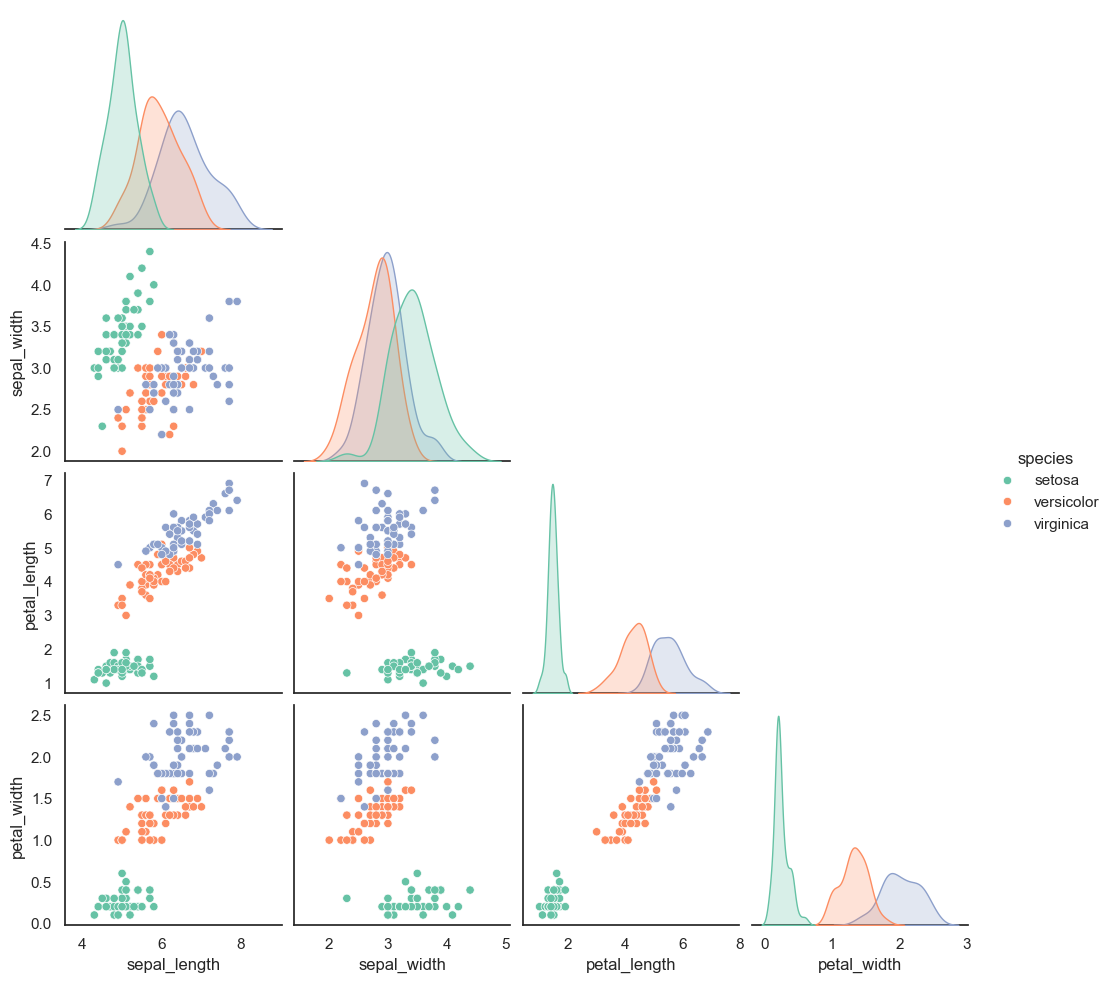

In [13]:
data = sns.load_dataset('iris')
sns.pairplot(data, hue='species',palette='Set2',corner=True)    
plt.show()

In [15]:
plt.suptitle('pairwise relationships in the iris dataset', y=1.02,fontsize =16,fontweight='bold')
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
corr_pairs = correlation_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind='quicksort', ascending=False)
print('sorted correlation pairs: \n', sorted_pairs)

sorted correlation pairs: 
 150         150           1.000000
4           4             1.000000
virginica   virginica     1.000000
versicolor  versicolor    1.000000
setosa      setosa        1.000000
            versicolor    0.962865
versicolor  setosa        0.962865
            virginica     0.956547
virginica   versicolor    0.956547
            setosa        0.949035
setosa      virginica     0.949035
150         setosa        0.871754
setosa      150           0.871754
versicolor  150           0.817941
150         versicolor    0.817941
            virginica     0.782561
virginica   150           0.782561
4           150          -0.117570
150         4            -0.117570
versicolor  4            -0.366126
4           versicolor   -0.366126
virginica   4            -0.426658
4           virginica    -0.426658
            setosa       -0.428440
setosa      4            -0.428440
dtype: float64


In [17]:
relationships = sorted_pairs[sorted_pairs < 1]
print('sorted correlation pairs excluding self-correlations: \n', relationships)

sorted correlation pairs excluding self-correlations: 
 setosa      versicolor    0.962865
versicolor  setosa        0.962865
            virginica     0.956547
virginica   versicolor    0.956547
            setosa        0.949035
setosa      virginica     0.949035
150         setosa        0.871754
setosa      150           0.871754
versicolor  150           0.817941
150         versicolor    0.817941
            virginica     0.782561
virginica   150           0.782561
4           150          -0.117570
150         4            -0.117570
versicolor  4            -0.366126
4           versicolor   -0.366126
virginica   4            -0.426658
4           virginica    -0.426658
            setosa       -0.428440
setosa      4            -0.428440
dtype: float64


In [18]:
relationships.tail(6)

versicolor  4            -0.366126
4           versicolor   -0.366126
virginica   4            -0.426658
4           virginica    -0.426658
            setosa       -0.428440
setosa      4            -0.428440
dtype: float64